In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# === Setup & imports ===
import os, glob, math, random, time
from pathlib import Path
from collections import defaultdict

from PIL import Image, UnidentifiedImageError

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import resnet50

# Repro
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

# Allowed image extensions
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

# Choose your dataset root here (edit this line)
DATA_ROOT = r"/content/drive/MyDrive/intel-mobileodt-cervical-cancer-screening"

# Patterns matching the Intel MobileODT layout; edit as needed
PATTERNS = [
    "train/train/Type_1/**/*.jpg", "train/train/Type_2/**/*.jpg", "train/train/Type_3/**/*.jpg",
    "train/train/Type_1/**/*.jpeg", "train/train/Type_2/**/*.jpeg", "train/train/Type_3/**/*.jpeg",
    "additional_Type_1_v2/Type_1/**/*.jpg", "additional_Type_2_v2/Type_2/**/*.jpg", "additional_Type_3_v2/Type_3/**/*.jpg",
    "additional_Type_1_v2/Type_1/**/*.jpeg", "additional_Type_2_v2/Type_2/**/*.jpeg", "additional_Type_3_v2/Type_3/**/*.jpeg",
]
INCLUDE_TEST = False
if INCLUDE_TEST:
    PATTERNS += ["test/test/**/*.jpg", "test/test/**/*.jpeg", "test/test/**/*.png"]

# Output/checkpoints directory
OUT_DIR = "checkpoints_ssl"
os.makedirs(OUT_DIR, exist_ok=True)


In [ ]:

# === File parsing check: list images and summarize by folder ===
def list_images(root, patterns):
    print(f"\n🔍 Scanning in root: {root}")
    paths = []
    for p in patterns:
        search_path = os.path.join(root, p)
        # print(f"  -> Searching pattern: {search_path}")  # uncomment to see each pattern
        found = glob.glob(search_path, recursive=True)
        paths.extend(found)
    # keep only valid image files by extension
    paths = [p for p in paths if Path(p).suffix.lower() in IMG_EXTS]
    # de-duplicate and sort
    return sorted(list(set(paths)))

img_paths = list_images(DATA_ROOT, PATTERNS)

# Group by parent directory (one level up from image)
folder_counts = defaultdict(int)
for p in img_paths:
    folder = str(Path(p).parent)
    folder_counts[folder] += 1

print("\n📂 Folders containing images:")
for folder, count in sorted(folder_counts.items()):
    print(f"  {folder} -> {count} images")

print(f"\n✅ Total images found: {len(img_paths)}")
print(f"✅ Total unique folders: {len(folder_counts)}")

if len(img_paths) == 0:
    raise RuntimeError("No images found. Check DATA_ROOT and PATTERNS.")



🔍 Scanning in root: /content/drive/MyDrive/intel-mobileodt-cervical-cancer-screening

📂 Folders containing images:
  /content/drive/MyDrive/intel-mobileodt-cervical-cancer-screening/additional_Type_1_v2/Type_1 -> 11 images
  /content/drive/MyDrive/intel-mobileodt-cervical-cancer-screening/additional_Type_2_v2/Type_2 -> 3456 images
  /content/drive/MyDrive/intel-mobileodt-cervical-cancer-screening/additional_Type_3_v2/Type_3 -> 1976 images
  /content/drive/MyDrive/intel-mobileodt-cervical-cancer-screening/train/train/Type_1 -> 2 images
  /content/drive/MyDrive/intel-mobileodt-cervical-cancer-screening/train/train/Type_2 -> 3 images
  /content/drive/MyDrive/intel-mobileodt-cervical-cancer-screening/train/train/Type_3 -> 1 images

✅ Total images found: 5449
✅ Total unique folders: 6


Found 2 images. Showing 5 examples...



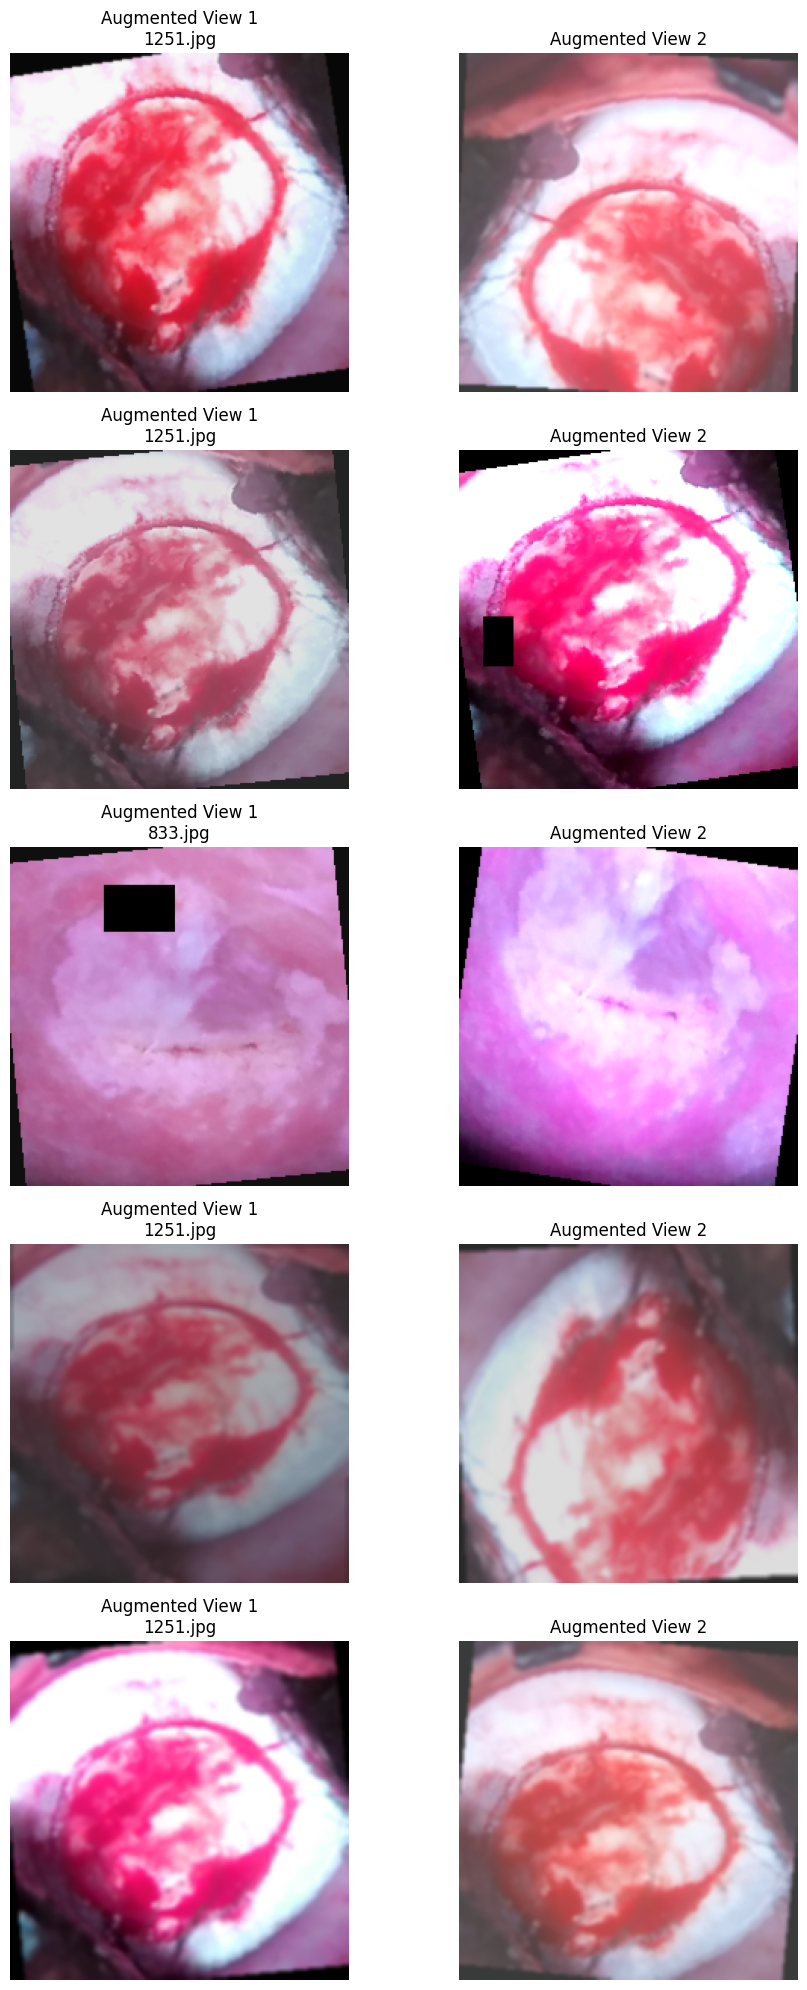

In [ ]:
# === Augmentation visualization ===
import matplotlib.pyplot as plt

def build_transforms(image_size=224):
    return transforms.Compose([
        transforms.RandomResizedCrop(image_size, scale=(0.5, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.05),
        transforms.RandomRotation(degrees=10, fill=0),
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.05),
        transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.25, scale=(0.01, 0.03), ratio=(0.3, 3.3)),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

# inverse normalization for display
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225],
)

def tensor_to_image(tensor):
    img = inv_normalize(tensor).clamp(0, 1)
    img = img.permute(1, 2, 0).numpy()
    return img

def visualize_augmentations(any_folder_or_root, image_size=224, num_samples=5):
    # harvest a quick list of images
    any_images = []
    for root, _, files in os.walk(any_folder_or_root):
        for f in files:
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp")):
                any_images.append(os.path.join(root, f))
    if len(any_images) == 0:
        raise RuntimeError("No images found in the specified folder.")

    transform = build_transforms(image_size)
    print(f"Found {len(any_images)} images. Showing {num_samples} examples...\n")

    plt.figure(figsize=(10, 4 * num_samples))
    for i in range(num_samples):
        img_path = random.choice(any_images)
        img = Image.open(img_path).convert("RGB")
        v1 = transform(img)
        v2 = transform(img)
        v1_img = tensor_to_image(v1)
        v2_img = tensor_to_image(v2)

        plt.subplot(num_samples, 2, 2*i + 1)
        plt.imshow(v1_img)
        plt.title(f"Augmented View 1\n{os.path.basename(img_path)}")
        plt.axis("off")

        plt.subplot(num_samples, 2, 2*i + 2)
        plt.imshow(v2_img)
        plt.title("Augmented View 2")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Pick a folder to preview (edit as needed)
preview_folder = os.path.join(DATA_ROOT, "train", "train", "Type_1")
visualize_augmentations(preview_folder, image_size=224, num_samples=5)


In [ ]:
# === Dataset & loss for SimCLR ===
def safe_open_rgb(path):
    try:
        with Image.open(path) as im:
            im.verify()
        return Image.open(path).convert("RGB")
    except (UnidentifiedImageError, OSError, ValueError):
        return None

class TwoCropsDataset(Dataset):
    def __init__(self, img_paths, transform, skipped_log_path=None):
        self.imgs = img_paths
        self.transform = transform
        self.skipped_log_path = skipped_log_path

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        path = self.imgs[idx]
        img = safe_open_rgb(path)
        if img is None:
            if self.skipped_log_path:
                with open(self.skipped_log_path, "a") as f:
                    f.write(path + "\n")
            return None
        v1 = self.transform(img)
        v2 = self.transform(img)
        return v1, v2

def drop_none_collate(batch):
    batch = [b for b in batch if b is not None]
    if len(batch) == 0:
        return None
    v1s, v2s = zip(*batch)
    return torch.stack(v1s), torch.stack(v2s)

class ProjectionMLP(nn.Module):
    def __init__(self, in_dim, hid=2048, out=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hid),
            nn.BatchNorm1d(hid),
            nn.ReLU(inplace=True),
            nn.Linear(hid, out)
        )
    def forward(self, x):
        return self.net(x)

def nt_xent_loss(z1, z2, temperature=0.2):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    B, D = z1.shape
    z = torch.cat([z1, z2], dim=0)     # [2B, D]
    sim = torch.matmul(z, z.T)         # cosine sim since normalized

    # Mask self-similarity
    mask = torch.eye(2 * B, dtype=torch.bool, device=z.device)
    sim.masked_fill_(mask, torch.finfo(sim.dtype).min)

    pos = torch.cat([torch.arange(B, 2 * B), torch.arange(0, B)]).to(z.device)
    pos_sim = sim[torch.arange(2 * B), pos] / temperature
    logits = sim / temperature

    log_sum_exp = torch.logsumexp(logits, dim=1)
    loss = -pos_sim + log_sum_exp
    return loss.mean()

In [ ]:
# === Build transforms, dataloader, and model ===
IMAGE_SIZE   = 224
BATCH_SIZE   = 64
EPOCHS       = 50
LR           = 1e-3
WEIGHT_DECAY = 1e-4
TEMPERATURE  = 0.2
LOG_EVERY    = 50

# Reuse the same transforms as in the visualization
transform = build_transforms(IMAGE_SIZE)

# Dataset + loader
skipped_log = os.path.join(OUT_DIR, "skipped_images.txt")
with open(skipped_log, "w") as f:
    f.write("Unreadable or corrupted images skipped:\n")

ds = TwoCropsDataset(img_paths, transform, skipped_log_path=skipped_log)
dl = DataLoader(
    ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,              # bump on Linux if desired
    pin_memory=torch.cuda.is_available(),
    drop_last=True,
    collate_fn=drop_none_collate
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Encoder (ResNet-50) + projector
encoder = resnet50(weights=None)
feat_dim = encoder.fc.in_features
encoder.fc = nn.Identity()

projector = ProjectionMLP(in_dim=feat_dim, hid=1024, out=128)

encoder.to(device)
projector.to(device)

opt = torch.optim.AdamW(
    list(encoder.parameters()) + list(projector.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)

total_steps = EPOCHS * max(1, len(dl))
def cosine_lr(step):
    return 0.5 * (1 + math.cos(math.pi * step / max(1, total_steps)))
sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=cosine_lr)

# (Optional) AMP for speed on GPU
use_amp = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler() if use_amp else None


Device: cuda


/tmp/ipython-input-3090729991.py:54: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if use_amp else None


In [ ]:
import matplotlib.pyplot as plt

# === Training loop ===
epoch_losses = []   # <-- store avg loss per epoch

step = 0
for epoch in range(1, EPOCHS + 1):
    encoder.train(); projector.train()
    running = 0.0
    t_epoch = time.time()
    print(f"Starting epoch {epoch}/{EPOCHS} (batches: {len(dl)})")

    for bidx, batch in enumerate(dl, start=1):
        if batch is None:
            continue
        x1, x2 = batch
        x1 = x1.to(device, non_blocking=True)
        x2 = x2.to(device, non_blocking=True)

        if scaler:
            with torch.amp.autocast("cuda"):
                z1 = projector(encoder(x1).flatten(1))
                z2 = projector(encoder(x2).flatten(1))
                loss = nt_xent_loss(z1, z2, temperature=TEMPERATURE)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
        else:
            z1 = projector(encoder(x1).flatten(1))
            z2 = projector(encoder(x2).flatten(1))
            loss = nt_xent_loss(z1, z2, temperature=TEMPERATURE)
            loss.backward()
            opt.step()

        sched.step()   # <-- FIXED: scheduler after optimizer step
        opt.zero_grad(set_to_none=True)

        running += loss.item()
        step += 1
        if bidx % LOG_EVERY == 0 or bidx == 1:
            print(f"  epoch {epoch} | batch {bidx}/{len(dl)} | loss {loss.item():.4f}")

    avg = running / max(1, len(dl))
    epoch_losses.append(avg)   # <-- track epoch loss

    dur = time.time() - t_epoch
    print(f"Epoch {epoch:03d}/{EPOCHS} | SimCLR loss: {avg:.4f} | {dur/60:.1f} min")

    # save per-epoch encoder weights
    save_path = os.path.join(OUT_DIR, f"ssl_backbone_resnet50_epoch{epoch}.pth")
    torch.save(encoder.state_dict(), save_path)
    print(f"Saved backbone: {save_path}")

# final save
final_path = os.path.join(OUT_DIR, "ssl_backbone_resnet50.pth")
torch.save(encoder.state_dict(), final_path)
print(f"✅ Done. Final backbone saved to: {final_path}")
print(f"🧾 Skipped image log saved to: {skipped_log}")

# === Plot loss vs epoch ===
plt.figure()
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("SimCLR loss")
plt.title("SimCLR Training Loss per Epoch")
plt.grid(True)

# save inside OUT_DIR so it sits with your checkpoints
loss_fig_path = os.path.join(DATA_ROOT, "simclr_loss_curve.png")
plt.savefig(loss_fig_path, bbox_inches="tight")
plt.close()

print(f"📉 Loss curve saved to: {loss_fig_path}")



Starting epoch 1/50 (batches: 85)
  epoch 1 | batch 1/85 | loss 5.3481
  epoch 1 | batch 50/85 | loss 3.7658
Epoch 001/50 | SimCLR loss: 4.2237 | 19.5 min
Saved backbone: /content/drive/MyDrive/intel-mobileodt-cervical-cancer-screening/checkpoints_ssl/ssl_backbone_resnet50_epoch1.pth
Starting epoch 2/50 (batches: 85)
  epoch 2 | batch 1/85 | loss 3.7924
  epoch 2 | batch 50/85 | loss 3.4100
Epoch 002/50 | SimCLR loss: 3.4392 | 18.8 min
Saved backbone: /content/drive/MyDrive/intel-mobileodt-cervical-cancer-screening/checkpoints_ssl/ssl_backbone_resnet50_epoch2.pth
Starting epoch 3/50 (batches: 85)
  epoch 3 | batch 1/85 | loss 3.3632
  epoch 3 | batch 50/85 | loss 2.9251
Epoch 003/50 | SimCLR loss: 3.0463 | 18.9 min
Saved backbone: /content/drive/MyDrive/intel-mobileodt-cervical-cancer-screening/checkpoints_ssl/ssl_backbone_resnet50_epoch3.pth
Starting epoch 4/50 (batches: 85)
  epoch 4 | batch 1/85 | loss 2.8680
  epoch 4 | batch 50/85 | loss 2.8553
Epoch 004/50 | SimCLR loss: 2.7584 |

In [ ]:
# === Load the pretrained backbone for downstream tasks ===
from torchvision.models import resnet50

encoder_downstream = resnet50(weights=None)
feat_dim = encoder_downstream.fc.in_features
encoder_downstream.fc = nn.Identity()

state = torch.load(os.path.join(OUT_DIR, "ssl_backbone_resnet50.pth"), map_location="cpu")
encoder_downstream.load_state_dict(state)

# Example: attach a simple classifier head (3 classes)
downstream_model = nn.Sequential(
    encoder_downstream,
    nn.Flatten(),
    nn.Linear(feat_dim, 3)
)

print("Downstream model ready.")
